In [50]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import importlib
sns.set_theme(style="whitegrid", context="talk")

sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2
    
from data_features.data_features import load_coupled_panel
from data_features.data_features import build_features
from data_features.data_features import make_t_plus_1_targets_winsorized

from models.models import add_har_rv_parallel
from models.models import feature_selection
from models.models import detect_markov_regime
from models.models import add_regime_probs_to_panel
from models.models import optimise_xgb_params_optuna
from models.models import two_regime_rolling_cv_per_country

from diagnostics.diagnostics import baseline_check
import diagnostics.diagnostics
importlib.reload(diagnostics.diagnostics)
from diagnostics.diagnostics import plot_cv_diagnostics

from trading.trading import compute_market_neutral_pnl_adaptive
from trading.trading import evaluate_trading_performance

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example of price/volatility data

/home/tatiana/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


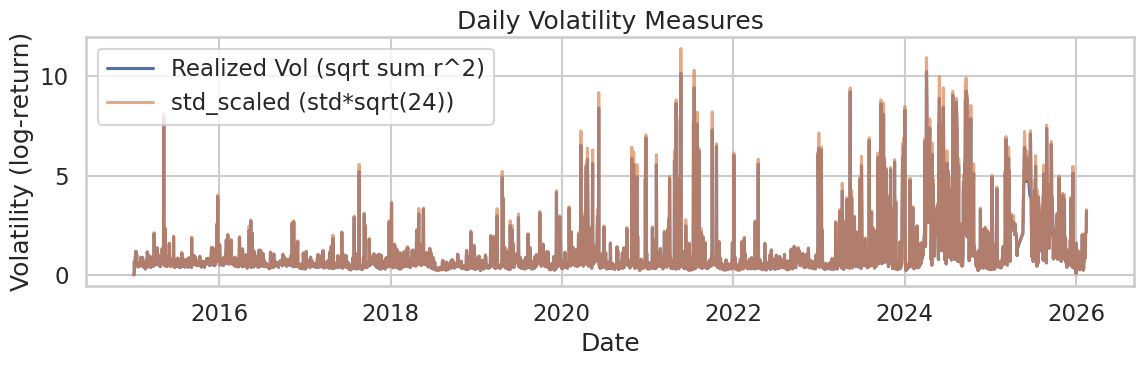

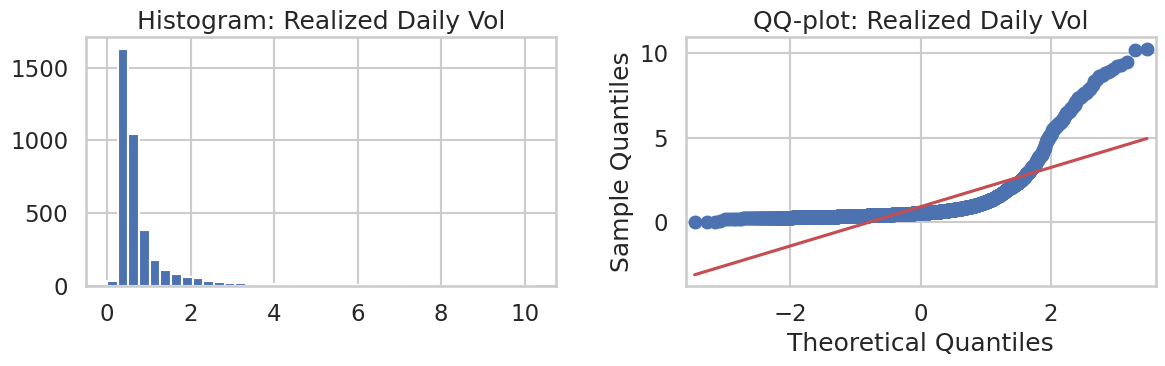

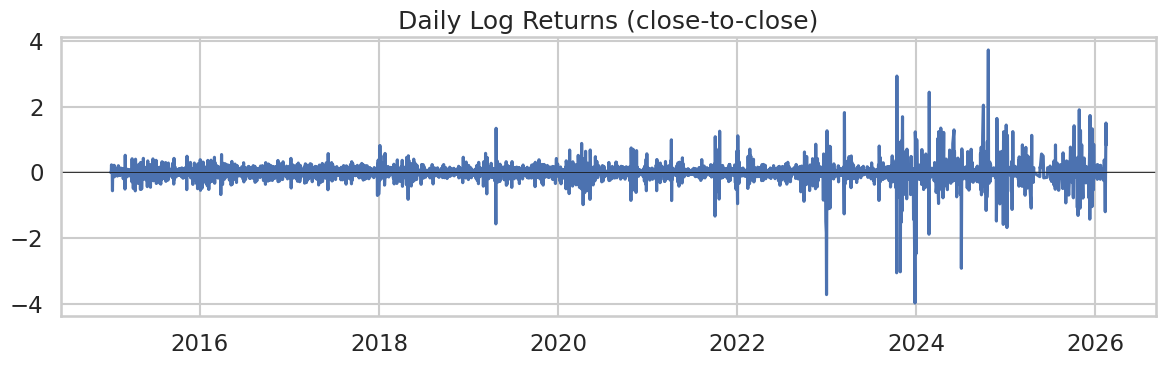

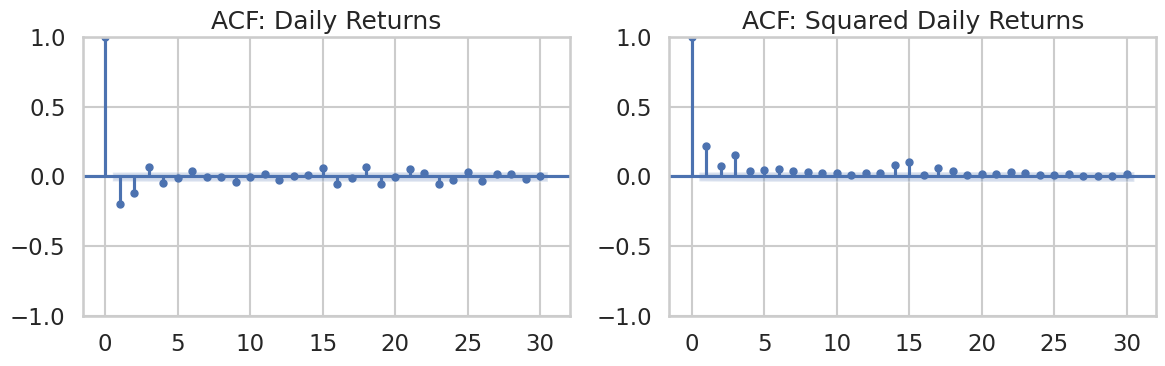

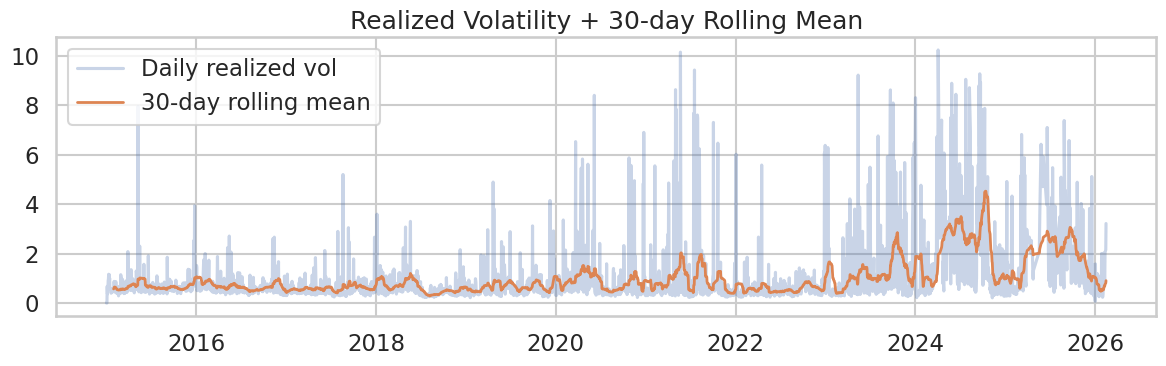

In [4]:
fn = "european_wholesale_electricity_price_data_hourly/France.csv"

# parse dates, prefer local datetime column for daily aggregation
df = pd.read_csv(fn, parse_dates=['Datetime (Local)'])

# columns: Country, ISO3 Code, Datetime (UTC), Datetime (Local), Price (EUR/MWhe)
# keep only the local datetime and price
df = df[['Datetime (Local)', 'Price (EUR/MWhe)']].copy()
df = df.rename(columns={'Datetime (Local)': 'datetime', 'Price (EUR/MWhe)': 'price'})
df = df.sort_values('datetime').set_index('datetime')
df.index = pd.to_datetime(df.index)  # ensure datetime index

# ---------------------------
# Hourly returns
# ---------------------------
# compute log returns (natural log)
df['log_price'] = np.log(df['price'].replace(0, np.nan))
df['hourly_ret'] = df['log_price'].diff()
df = df.dropna(subset=['hourly_ret'])  # drop first NA

# ---------------------------
# Daily volatility measures
# ---------------------------
# Option A: Realized volatility (square-root of sum of squared intraday returns)
# Option B: Daily std of hourly returns scaled by sqrt(24) (if hours per day ~24)
# Guard against days with missing hours (e.g., DST or missing data)
min_hours_required = 20  # drop days with fewer than this many hourly observations

# attach a date column for grouping (local date)
df['date'] = df.index.normalize()  # midnight-normalized date

group = df.groupby('date')

# count hours per day
counts = group['hourly_ret'].count().rename('n_hours')

daily = pd.DataFrame({
    'n_hours': counts,
})

# realized volatility: sqrt(sum(r_i^2))
daily['realized_vol'] = group['hourly_ret'].apply(lambda x: np.sqrt(np.sum(x.values**2)))

# scaled std: std(hourly returns) * sqrt(24)  (common approximation)
daily['std_scaled'] = group['hourly_ret'].std() * np.sqrt(24)

# daily log return using last observation each day (close-to-close)
daily_close = df['log_price'].resample('D').last()
daily['daily_log_return'] = daily_close.diff().reindex(daily.index)

# filter days with too few hours (optional, recommended)
daily = daily[daily['n_hours'] >= min_hours_required]

# drop any rows with NaNs where it matters
daily = daily.dropna(subset=['realized_vol', 'std_scaled', 'daily_log_return'])

# ---------------------------
# Plotting
# ---------------------------
plt.rcParams['figure.figsize'] = (12, 4)

# Time series of realized volatility
plt.figure()
plt.plot(daily.index, daily['realized_vol'], label='Realized Vol (sqrt sum r^2)')
plt.plot(daily.index, daily['std_scaled'], label='std_scaled (std*sqrt(24))', alpha=0.7)
plt.legend()
plt.title('Daily Volatility Measures')
plt.xlabel('Date')
plt.ylabel('Volatility (log-return)')
plt.tight_layout()
plt.show()

# Histogram + QQplot of daily volatility
plt.figure()
plt.subplot(1,2,1)
plt.hist(daily['realized_vol'].dropna(), bins=40)
plt.title('Histogram: Realized Daily Vol')
plt.subplot(1,2,2)
qqplot(daily['realized_vol'].dropna(), line='s', ax=plt.gca())
plt.title('QQ-plot: Realized Daily Vol')
plt.tight_layout()
plt.show()

# Time series of daily returns 
plt.figure()
plt.plot(daily.index, daily['daily_log_return'])
plt.title('Daily Log Returns (close-to-close)')
plt.axhline(0, color='k', linewidth=0.6)
plt.tight_layout()
plt.show()

# ACF of returns and squared returns
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_acf(daily['daily_log_return'].dropna(), lags=30, ax=plt.gca(), title='ACF: Daily Returns')
plt.subplot(1,2,2)
plot_acf(daily['daily_log_return'].dropna()**2, lags=30, ax=plt.gca(), title='ACF: Squared Daily Returns')
plt.tight_layout()
plt.show()

# Rolling volatility plot 
plt.figure()
rolling = daily['realized_vol'].rolling(window=30).mean()
plt.plot(daily.index, daily['realized_vol'], alpha=0.3, label='Daily realized vol')
plt.plot(daily.index, rolling, label='30-day rolling mean', linewidth=2)
plt.legend()
plt.title('Realized Volatility + 30-day Rolling Mean')
plt.tight_layout()
plt.show()

# Demo / current results

### Loading data, printing contents

In [8]:
panel = load_coupled_panel("daily_merged_full_germany.csv", 
                           "daily_merged_full_france.csv")

print(panel.columns.tolist())
panel.head()

['DATE', 'DE_realized_vol', 'DE_daily_log_return', 'DE_temp_C', 'DE_wind_speed', 'DE_precip', 'DE_Biomass_Actual_Aggregated', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Coal_derived_gas_Actual_Aggregated', 'DE_Fossil_Gas_Actual_Aggregated', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Fossil_Oil_Actual_Aggregated', 'DE_Geothermal_Actual_Aggregated', 'DE_Hydro_Pumped_Storage_Actual_Aggregated', 'DE_Hydro_Pumped_Storage_Actual_Consumption', 'DE_Hydro_Run_of_river_and_poundage_Actual_Aggregated', 'DE_Hydro_Water_Reservoir_Actual_Aggregated', 'DE_Other_Actual_Aggregated', 'DE_Other_renewable_Actual_Aggregated', 'DE_Solar_Actual_Aggregated', 'DE_Solar_Actual_Consumption', 'DE_Waste_Actual_Aggregated', 'DE_Wind_Offshore_Actual_Aggregated', 'DE_Wind_Onshore_Actual_Aggregated', 'DE_Wind_Onshore_Actual_Consumption', 'DE_Fossil_Brown_coal_Lignite_Actual_Consumption', 'DE_Fossil_Coal_derived_gas_Actual_Consumption', 'DE_Fossil_Gas_Actual_Consumption', 'DE_Fossil_Hard_coal_Actual

,DATE,DE_realized_vol,DE_daily_log_return,DE_temp_C,DE_wind_speed,DE_precip,DE_Biomass_Actual_Aggregated,DE_Fossil_Brown_coal_Lignite_Actual_Aggregated,DE_Fossil_Coal_derived_gas_Actual_Aggregated,DE_Fossil_Gas_Actual_Aggregated,...,FR_Wind_Onshore_Actual_Consumption,FR_Energy_storage_Actual_Aggregated,FR_Energy_storage_Actual_Consumption,FR_Fossil_Oil_Actual_Consumption,FR_total_generation,FR_wind_total,FR_wind_share,FR_solar_total,FR_solar_share,FR_load_MW
0,2015-01-30,0.581994,0.061458,0.171051,3.714694,0.000136,4702.510000,17854.666250,0.0,1492.348750,...,NaN,NaN,NaN,NaN,74468.000000,NaN,NaN,0.000000,0.000000,68927.000000
1,2015-01-31,0.460251,-0.055179,-0.200287,3.407336,0.000074,4749.933125,17275.562604,0.0,1760.052604,...,NaN,NaN,NaN,NaN,76474.666667,NaN,NaN,393.000000,0.005139,68780.250000
2,2015-02-01,0.445206,0.051841,-0.188416,3.670489,0.000098,4738.595313,17634.286458,0.0,1650.192917,...,NaN,NaN,NaN,NaN,76911.458333,NaN,NaN,408.583333,0.005312,67595.166667
3,2015-02-02,0.588018,0.253294,-0.011078,4.111092,0.000097,4689.908958,18220.183854,0.0,2545.774271,...,NaN,NaN,NaN,NaN,80408.208333,NaN,NaN,459.250000,0.005711,76580.708333
4,2015-02-03,0.732238,-0.116378,-1.376923,3.025634,0.000026,4682.821042,17978.253125,0.0,3772.018021,...,NaN,NaN,NaN,NaN,81256.541667,NaN,NaN,309.583333,0.003810,79182.291667


### Building a few lagged/cross-country features out of raw data

In [9]:
panel_feat = build_features(panel)

### HAR-RV modeling and diagnostics block
- Longer observation window for Germany and shorter for France yields better results, due to difference in their regime/s structure
- This method is definitely superior to GARCH(1,1) (used previously) for this data and is used for further steps.
- It cannot efficiently account for certain data features, such as weekly patterns

In [10]:
panel_harrv, metrics_harrv = add_har_rv_parallel(
    panel_feat,
    min_obs = 150,
    window={"DE": 500, "FR": 200}
)
metrics_harrv

{'DE': {'spearman_ic': np.float64(0.6690285071078795),
  'rmse': 0.9369223113919122,
  'mae': 0.4747859920188156},
 'FR': {'spearman_ic': np.float64(0.6659635164543802),
  'rmse': 1.2328451103041016,
  'mae': 0.5624771972862375}}


--- DE Baseline diagnostics ---
rows: 4034
nan sigma: 150 (3.7%)
nan realized: 0 (0.0%)
valid pairs: 3884
spearman(log real, log sigma): 0.6690


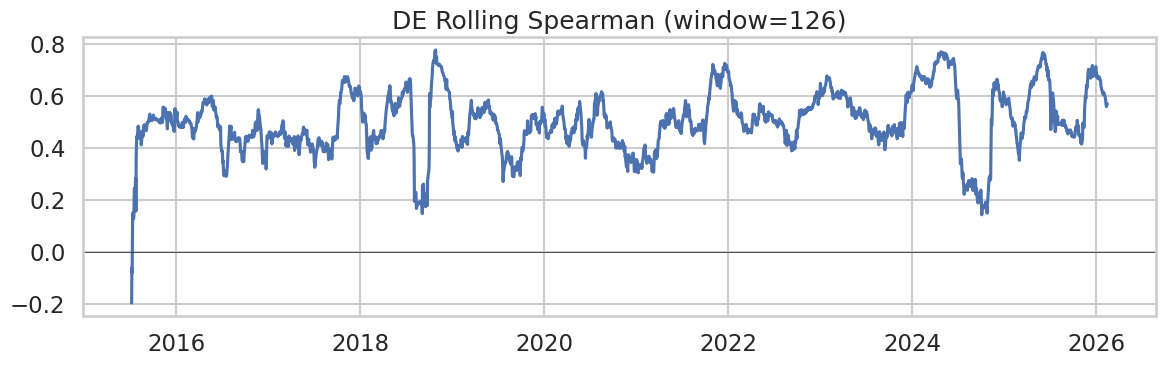

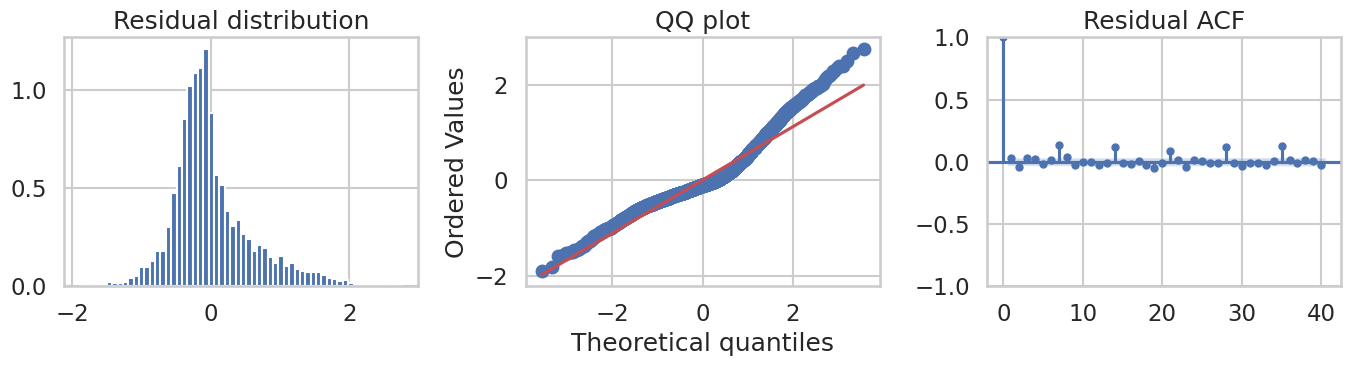

residual mean=0.0114  std=0.5770  skew=1.0448

--- FR Baseline diagnostics ---
rows: 4034
nan sigma: 150 (3.7%)
nan realized: 0 (0.0%)
valid pairs: 3884
spearman(log real, log sigma): 0.6660


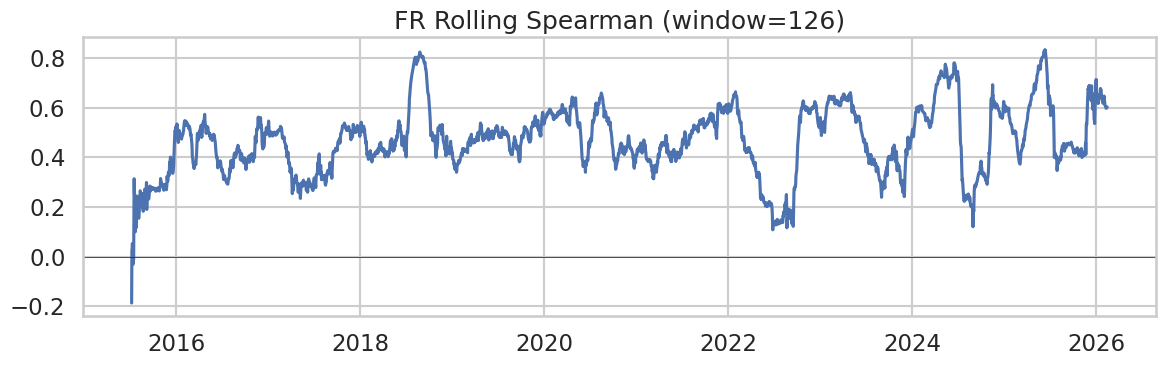

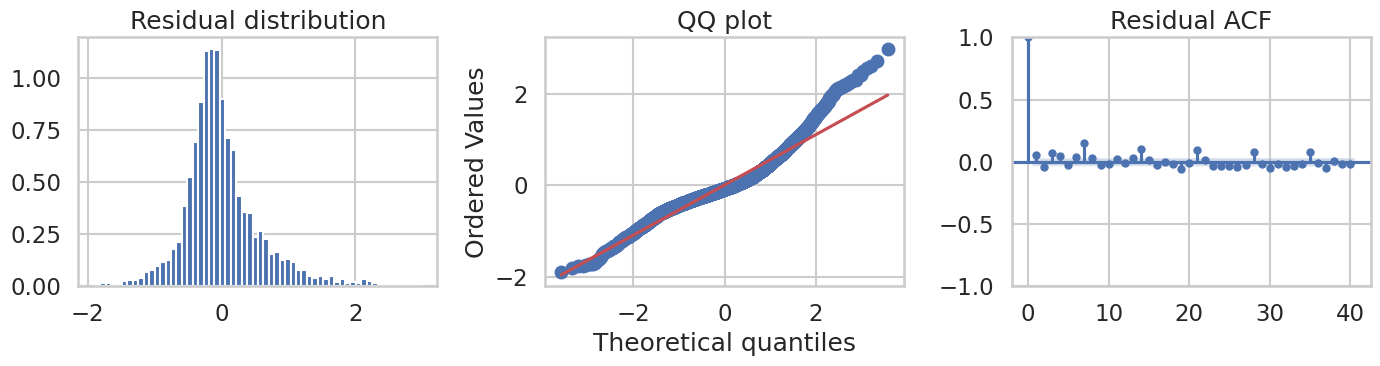

residual mean=0.0054  std=0.5679  skew=0.9557


In [18]:
roll_de = baseline_check(panel_harrv, "DE")

roll_fr = baseline_check(panel_harrv, "FR")

### Creating prediction target: computing vol residuals (realized vol - baseline), shifting to t+1

In [19]:
panel_harrv_res = make_t_plus_1_targets_winsorized(panel_harrv, winsor_pct=0)

[target stats] DE_residual_target: n=3884  mean=0.011  std=0.577  skew=1.045  [-1.12, 1.80]
[target stats] FR_residual_target: n=3884  mean=0.005  std=0.568  skew=0.956  [-1.25, 1.93]


### Selecting most important features for further ML training
- Runs pre-filter on full set first, then rolling windows, like in CV
- Hard limits on pre-filtered and final selection can be set
- Regime-aware (uses vol z-score as detector), feature importance can be adjusted based on regime
- However, still not ideal and can:
    - Miss features that are important, like nuclear for FR in post 2022 regime
    - Select redundant features, unless explicitly prohibited

In [21]:
selected_features, diagnostics = feature_selection(panel_harrv_res, 
                                                    train_window = 1200,
                                                    prefilter_top_k = 20,
                                                    max_features = 10,
                                                    freq_threshold = 0.70,
                                                    freq_threshold_regime = 0.45)


=== FEATURE SELECTION DIAGNOSTICS ===
Folds: 178  (pre-2022: 107, post-2022: 71)
Train window: 1200 days (rolling)
Freq threshold: global=0.7, per-regime=0.45
Vol zscore regime split: True
Avg prefilter kept: DE=20.0, FR=20.0
Avg selected per fold: DE=9.8, FR=9.7
Stable DE: 10  Stable FR: 9
Calendar features forced (prefixed only): 0
Union total: 18

--- Fold-averaged metrics ---
DE: train IC=0.4936  test IC=0.3505  gap=0.1431
FR: train IC=0.4178  test IC=0.2416  gap=0.1762

Stable DE features: ['DE_daily_log_return', 'DE_res_load', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Gas_Actual_Aggregated', 'DE_load_MW_lag7', 'DE_wind_speed', 'DE_Hydro_Pumped_Storage_Actual_Aggregated', 'VOL_SPREAD', 'DE_Hydro_Water_Reservoir_Actual_Aggregated']
Stable FR features: ['FR_daily_log_return', 'FR_Fossil_Gas_Actual_Aggregated', 'FR_wind_speed', 'FR_load_MW_lag7', 'FR_Hydro_Water_Reservoir_Actual_Aggregated', 'FR_Fossil_Hard_coal_Actual_Aggr

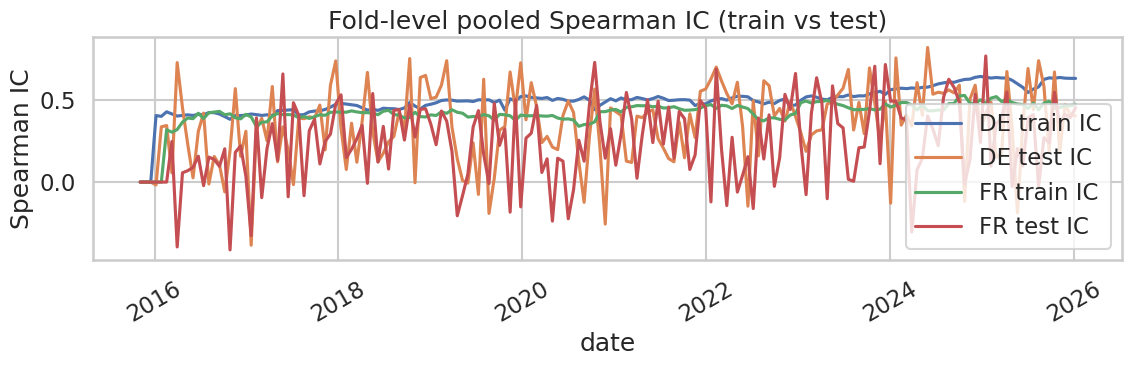

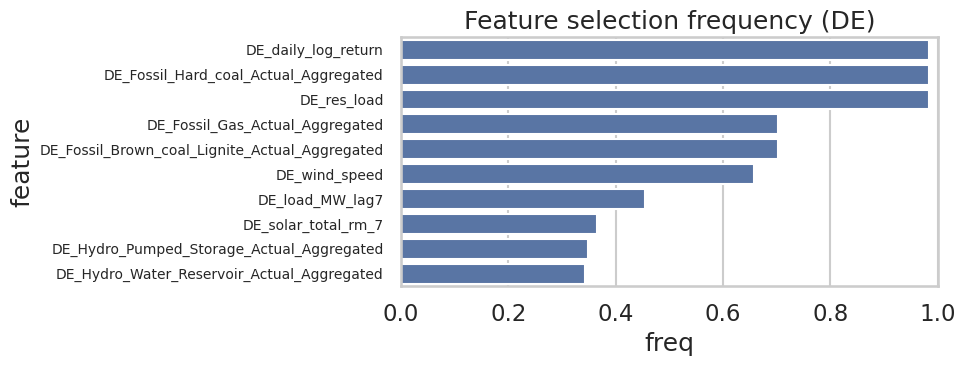

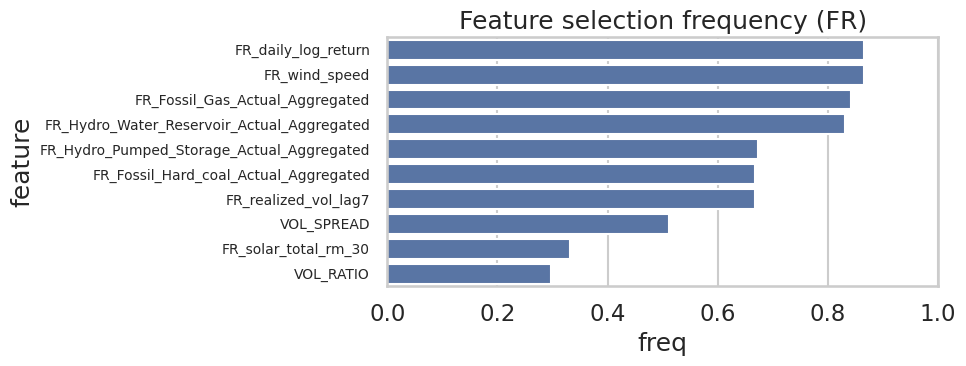

In [23]:
# assume `diagnostics` exists from function call
folds = diagnostics["folds"].copy()
folds["train_until"] = pd.to_datetime(folds["train_until"])

# 1) Train / Test IC over folds
plt.figure(figsize=(12,4))
if "DE_train_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_train_ic", label="DE train IC")
if "DE_test_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_test_ic", label="DE test IC")
if "FR_train_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_train_ic", label="FR train IC")
if "FR_test_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_test_ic", label="FR test IC")
plt.title("Fold-level pooled Spearman IC (train vs test)")
plt.ylabel('Spearman IC')
plt.xlabel('date')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

"""
# 2) Train / Test RMSE over folds
plt.figure(figsize=(12,4))
if "DE_train_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_train_rmse", label="DE train RMSE")
if "DE_test_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_test_rmse", label="DE test RMSE")
if "FR_train_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_train_rmse", label="FR train RMSE")
if "FR_test_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_test_rmse", label="FR test RMSE")
plt.title("Fold-level RMSE (train vs test)")
plt.ylabel('RMSE')
plt.xlabel('date')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()
"""
# 3) Feature selection frequency (top 15) per country
freq_de = diagnostics.get("freq_de", {})
freq_fr = diagnostics.get("freq_fr", {})
def plot_top_freq(freq_map, title, top_n=10):
    if not freq_map:
        print("No freq data for", title)
        return
    df_freq = pd.DataFrame(list(freq_map.items()), columns=["feature","freq"])
    df_freq = df_freq.sort_values("freq", ascending=False).head(top_n)
    plt.figure(figsize=(10, max(4, 0.2*len(df_freq))))
    sns.barplot(x="freq", y="feature", data=df_freq)
    plt.yticks(fontsize=10) 
    plt.title(title)
    plt.xlim(0,1)
    plt.tight_layout()
    plt.show()

plot_top_freq(freq_de, "Feature selection frequency (DE)")
plot_top_freq(freq_fr, "Feature selection frequency (FR)")

In [26]:
## Selected feature override -- using hand-picked sensible variables, removing redundancy and trying to handle overfitting
selected_features = ['DE_daily_log_return','DE_res_load', 'DE_Fossil_Hard_coal_Actual_Aggregated',
                     'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'VOL_SPREAD',
                     
                     'FR_res_load','FR_daily_log_return', 
                     'FR_Fossil_Gas_Actual_Aggregated', 
                     'FR_Hydro_Water_Reservoir_Actual_Aggregated','FR_realized_vol_lag7']

### An example of HMM regime detection for France and diagnostics
- Just a demo here, used on full data sample
- This function is further used in the exp. window logic with XGBoost to avoid lookahead
- Used on **log of realized volatility** in the main file, here just on raw values, again, just for demo
- Clear regime separation can be seen from state counts and their means below (should be significantly different)

In [24]:
fr_regimes, fr_diag = detect_markov_regime(
    panel_harrv_res,
    residual_col="FR_realized_vol"
)

print('transition matrix = \n', fr_diag["transition_matrix"])
print('state means = ', fr_diag["means"])
print('state counts = ', fr_diag["state_counts"])

transition matrix = 
 [[0.92413873 0.07586127]
 [0.21688328 0.78311672]]
state means =  [0.53177288 2.83507612]
state counts =  [3021 1013]


Text(0.5, 0, 'time axis')

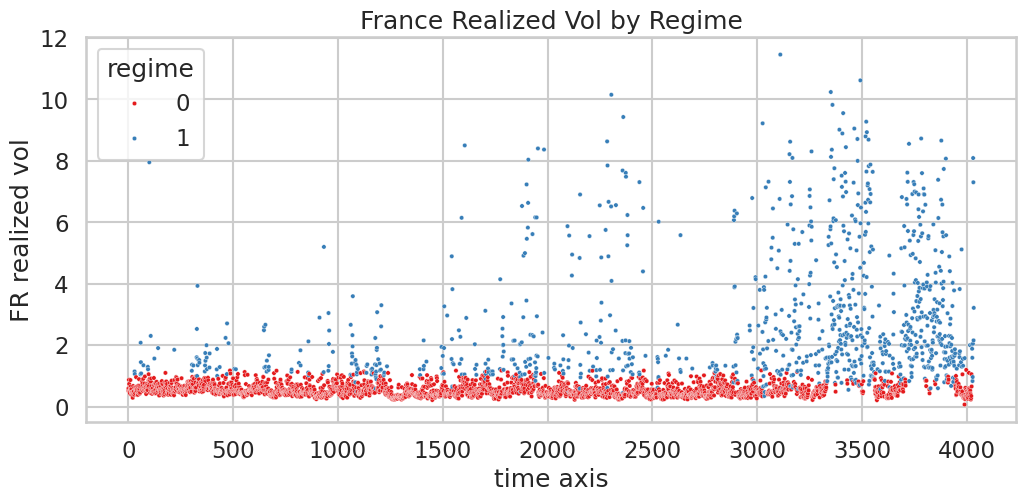

In [25]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=fr_regimes.index,
    y=fr_regimes["FR_realized_vol"],
    hue=fr_regimes["regime"],
    palette="Set1",
    s=10
)
plt.title("France Realized Vol by Regime")
plt.ylabel('FR realized vol')
plt.xlabel('time axis')

### Optuna XFGBoost hyperparameter optimization
- Running on post-2022 regime, so about 500 days training, 250 validation
- Using selected feature subset
- Optimization needs to be done in the main CV, here optimization is basically just for one regime

In [27]:
best_de = optimise_xgb_params_optuna(
  panel_harrv_res,
  features=[f for f in selected_features if f.startswith('DE_')],
  target='DE_residual_target',
  train_cutoff='2022-07-01',
  val_cutoff='2024-01-01',
  n_trials=150,
)
best_fr = optimise_xgb_params_optuna(
  panel_harrv_res,
  features=[f for f in selected_features if f.startswith('FR_')],
  target='FR_residual_target',
  train_cutoff='2022-07-01',
  val_cutoff='2024-01-01',
  n_trials=150,
)

Best trial: 43. Best value: 0.489849: 100%|███| 150/150 [00:18<00:00,  8.25it/s]


Best IC: 0.4898  |  Params: {'max_depth': 4, 'eta': 0.07989370115057116, 'subsample': 0.8191267227886193, 'colsample_bytree': 0.8066660405573772, 'lambda': 20.48016519408309, 'alpha': 21.715350828247523, 'min_child_weight': 13, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'seed': 42, 'nthread': 1, 'verbosity': 0}


Best trial: 19. Best value: 0.381899: 100%|███| 150/150 [00:14<00:00, 10.64it/s]

Best IC: 0.3819  |  Params: {'max_depth': 3, 'eta': 0.021895715278407255, 'subsample': 0.7126726522628793, 'colsample_bytree': 0.8062028759538196, 'lambda': 22.478038900953624, 'alpha': 0.4420281129668848, 'min_child_weight': 49, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'seed': 42, 'nthread': 1, 'verbosity': 0}


### Main XGBoost residual vol forecasting block and diagnostics
- Running in rolling windows now, to account for persistency in regime changes (thus older data being less useful to predict in current regime).
- Tried a range of windows, found optimum at 1200 days.
- Overfitting (train/test) gap is 0.12 for DE and 0.15 for FR, which corresponds some 70-75% retention. More reasonable than earlier (0.2), but lower is better, maybe 0.07-0.1 would be good.
- Vol z-score as a regime detector works better than HMM. Not yet sure why.

In [43]:
panel_with_regimes, regime_diags = add_regime_probs_to_panel(
    panel_harrv_res, countries=['DE', 'FR'])

all_preds, cv_metrics = two_regime_rolling_cv_per_country(
    panel_with_regimes, selected_features,
    #xgb_params=best_de,
    train_window = 1200,
    use_markov={'DE': False, 'FR': False},       
    use_per_regime_models = False,
    use_vol_zscore={'DE': True, 'FR': True},   
)

[DE] HMM fitted on full panel. means=[-0.769  0.458]  state_counts=[2824 1210]  filtered=True (no lookahead)
[FR] HMM fitted on full panel. means=[-0.694  0.673]  state_counts=[2939 1095]  filtered=True (no lookahead)
=== SUMMARY ===
Pooled IC: 0.3376621742519339
Per-country IC: {'DE': 0.38939427102266494, 'FR': 0.27894237190575893}
Mean fold ICs — DE: 0.3688  FR: 0.2412
Mean RMSE (fold mean): 0.4982
Pooled RMSE / MAE: 0.5294 / 0.3850


In [46]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

all_preds = all_preds.sort_values('DATE').reset_index(drop=True)

for c in ['DE', 'FR']:
    idx = all_preds[all_preds['COUNTRY'] == c].index  # integer positions in all_preds
    sub = all_preds.loc[idx].copy()

    err = (sub['pred'] - sub['true']).reset_index(drop=True)

    # Build AR(7) design matrix on the error series
    X_ar = pd.concat([err.shift(i) for i in range(1, 8)], axis=1)
    X_ar.columns = [f'lag_{i}' for i in range(1, 8)]

    valid = X_ar.dropna().index  # rows where all 7 lags are available
    X_fit = sm.add_constant(X_ar.loc[valid])
    y_fit = err.loc[valid]

    ar_model = OLS(y_fit, X_fit).fit()
    correction = ar_model.fittedvalues  # indexed by valid (0-based within sub)

    # Map back: valid is 0-based within sub, idx gives all_preds positions
    all_preds.loc[idx[valid], 'pred'] -= correction.values

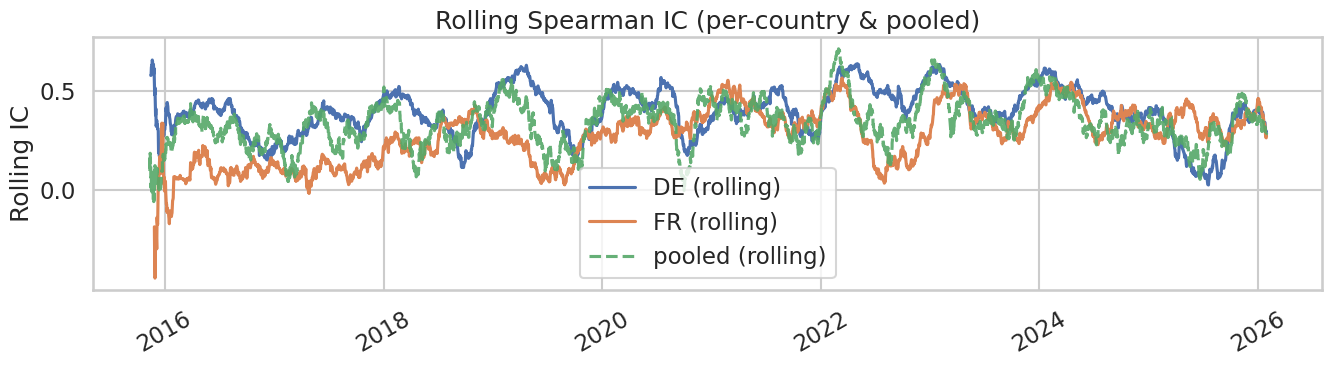

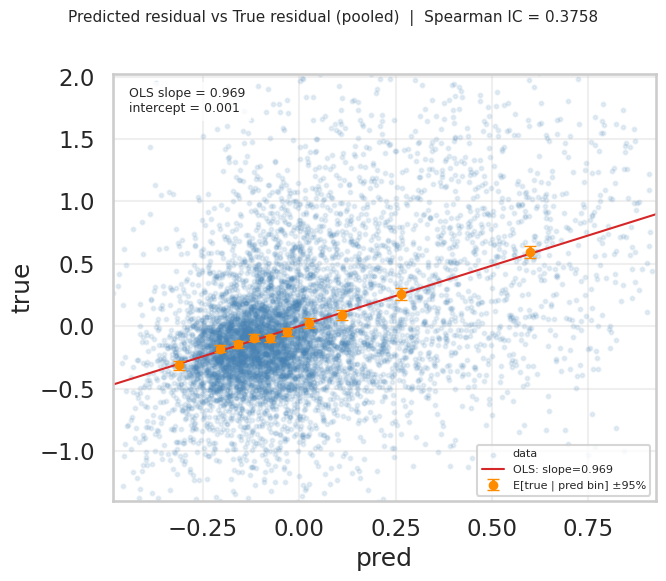

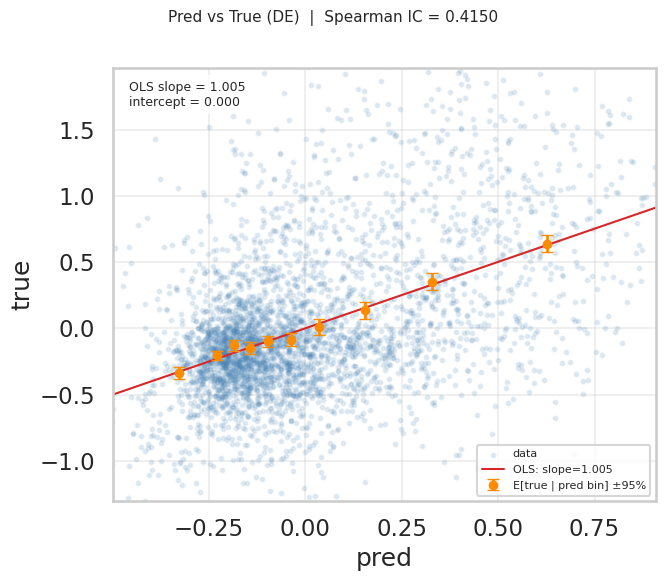

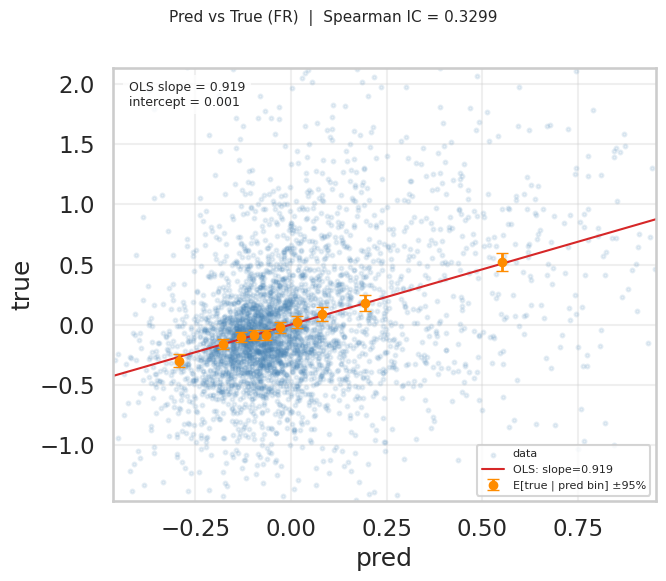

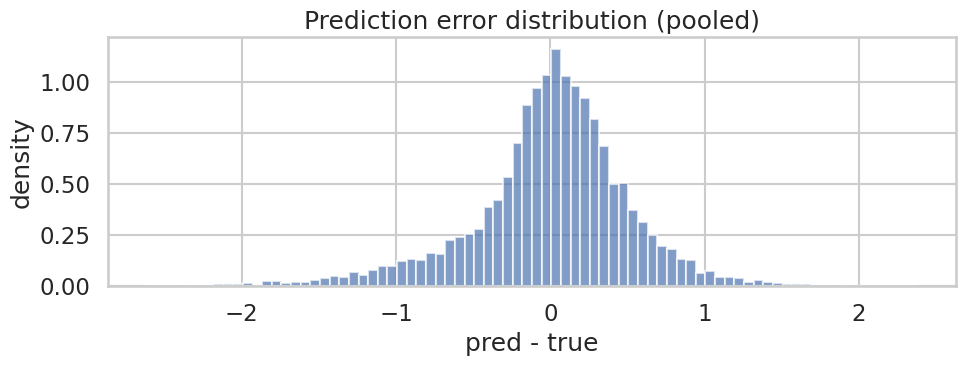

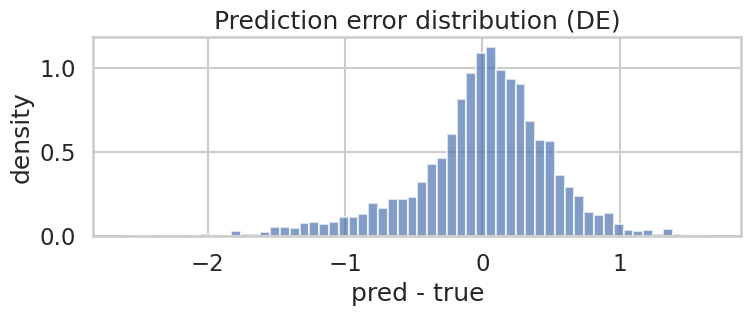

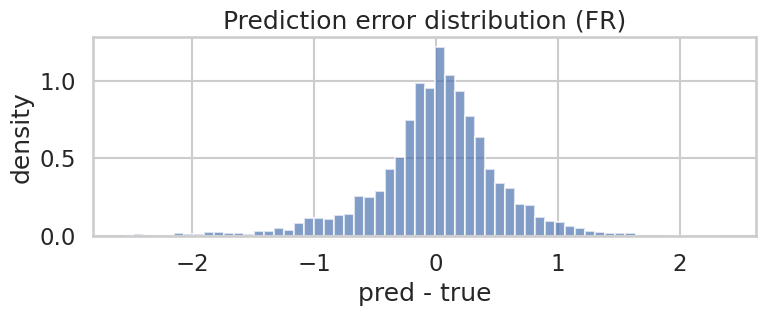

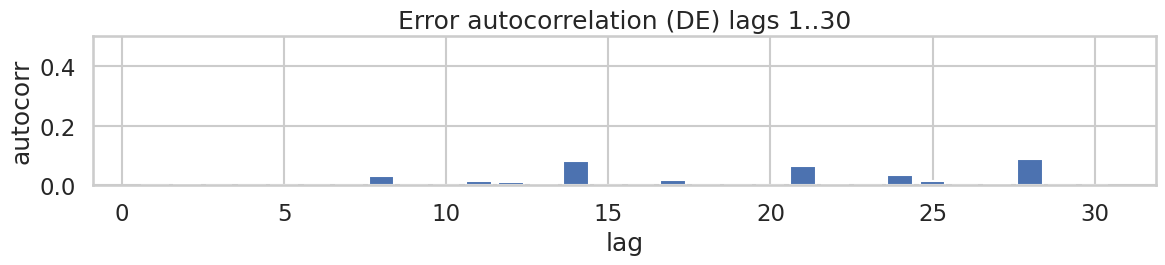

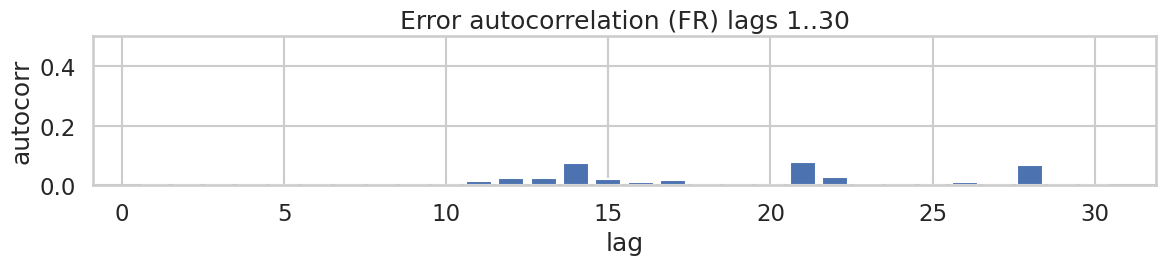

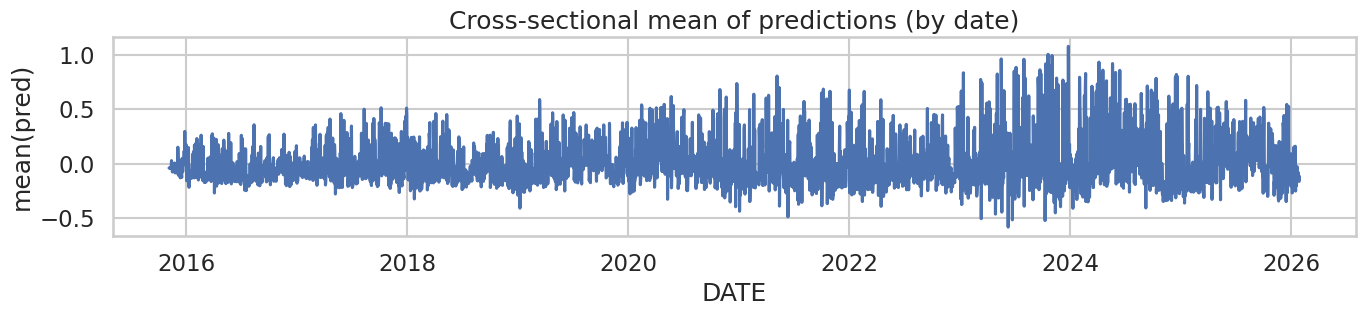

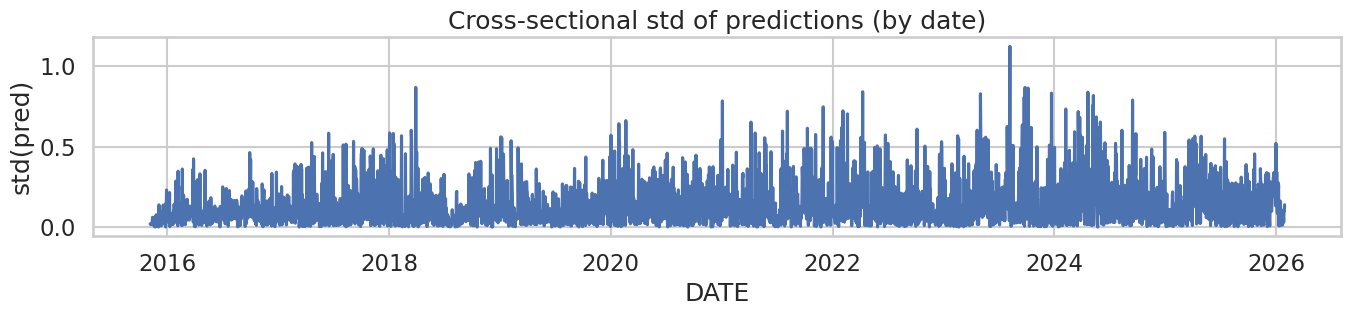

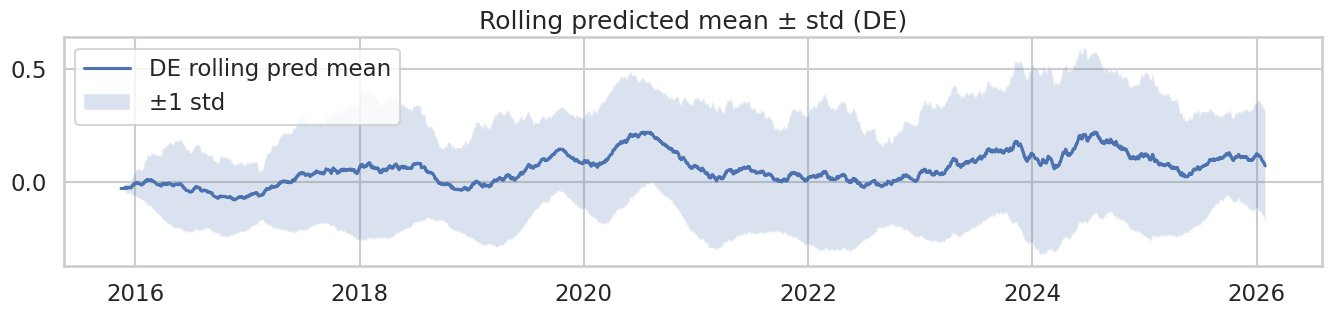

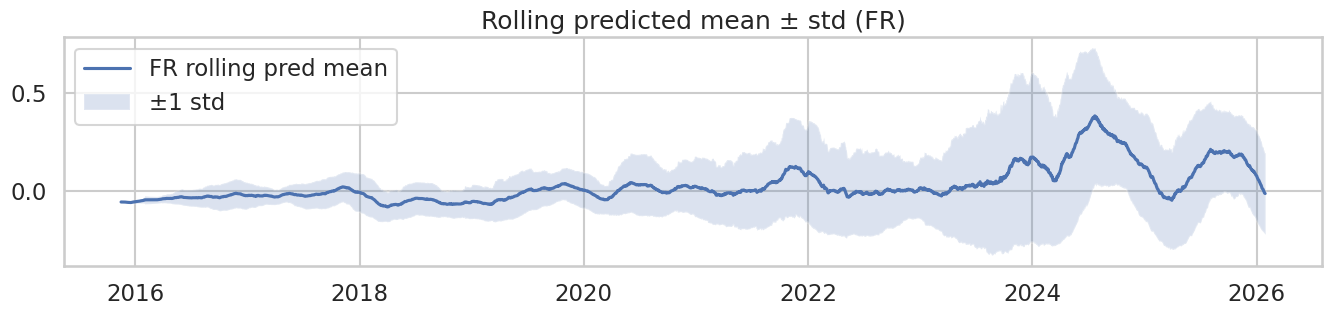

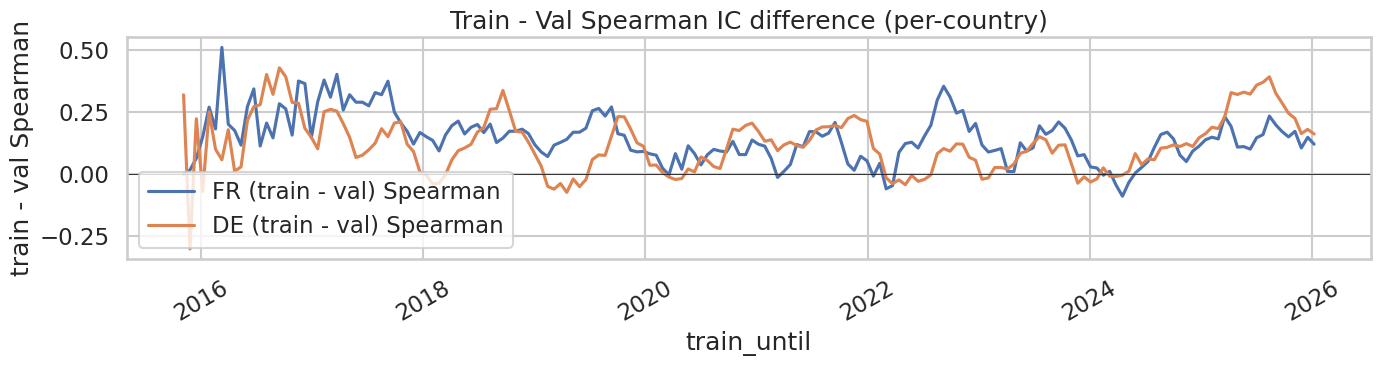

diff. IC train-val, FR: 0.146
diff. IC train-val, DE: 0.12
=== SUMMARY ===
Pooled IC: 0.3376621742519339
Per-country IC: {'DE': 0.38939427102266494, 'FR': 0.27894237190575893}
Mean fold ICs (DE/FR): 0.36884224861101444 0.24115514937770055
Mean RMSE (fold mean): 0.4982311718002006
Pooled RMSE / MAE: 0.5293863414079708 0.3849821309634925


In [47]:
plot_cv_diagnostics(all_preds, cv_metrics)

### Trading strategy + diagnostics block 

- Input is to be optimized further
- Realistic execution modeling (slippage, transaction costs) to be further developed

In [48]:
## cost right now is 50 bps

bt = compute_market_neutral_pnl_adaptive(all_preds, cost_bps = 0.005)#, ewma_alpha = 0.1, rebalance_thr = 0.01, lookback=30)

In [51]:
diag = evaluate_trading_performance(bt)

=== Trading Performance ===
Sharpe Ratio: 2.0934
Max Drawdown: -5.3601
Win Rate: 44.73%
Avg Daily Turnover: 0.9013
Total PnL: 122.970172
Total Cost: 16.845000
PnL Before Cost: 139.815172
Cost Coverage Ratio: 8.300099


In [40]:
daily_pnl = bt.groupby('DATE')['pnl'].sum()
print(daily_pnl.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

left = abs(daily_pnl.quantile(0.1))
right = daily_pnl.quantile(0.9)
print("Asymmetry ratio (right/left):", right/left)

0.10   -0.204922
0.25   -0.066390
0.50   -0.005000
0.75    0.112662
0.90    0.322259
Name: pnl, dtype: float64
Asymmetry ratio (right/left): 1.5725943865598162


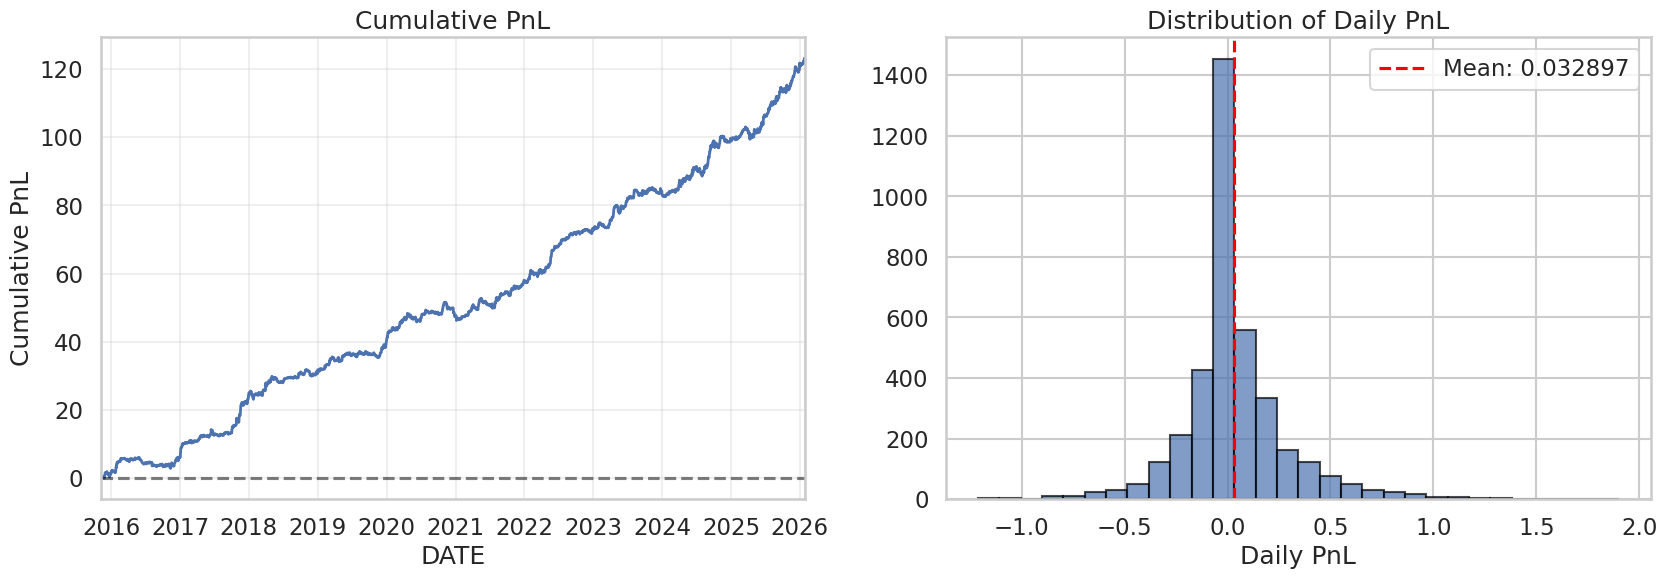

In [41]:
# 3. Cumulative PnL
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
cum_pnl = daily_pnl.cumsum()
cum_pnl.plot(ax=axes[0], title='Cumulative PnL', linewidth=2)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative PnL')
axes[0].grid(True, alpha=0.3)

# 4. Daily PnL distribution
axes[1].hist(daily_pnl.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(daily_pnl.mean(), color='red', linestyle='--',
                   label=f'Mean: {daily_pnl.mean():.6f}')
axes[1].set_title('Distribution of Daily PnL')
axes[1].set_xlabel('Daily PnL')
axes[1].legend();